#  HITL

In [1]:
from langchain_core.tools import tool

@tool
def convert_currency(amount: float, from_currency: str, to_currency: str):
    """美元兑欧元的货币转换"""
    print(f"Converting {amount} from {from_currency} to {to_currency}")
    return f"{amount * 1.1:.2f} {to_currency}"  # fixed mock rate

In [2]:

import dotenv
dotenv.load_dotenv('.env')


True

In [3]:
import os
from pymongo import MongoClient
from langgraph.checkpoint.mongodb import MongoDBSaver
from langchain_deepseek import ChatDeepSeek

client = MongoClient(host=os.getenv("MONGO_HOST"),
                     port=int(os.getenv("MONGO_PORT")),
                     username=os.getenv("MONGO_USER"),
                     password=os.getenv("MONGO_PASSWORD"))
memory = MongoDBSaver(client)

model = ChatDeepSeek(model="deepseek-chat", 
                     api_key=os.getenv("DEEPSEEK_API_KEY"),
                     base_url=os.getenv("DEEPSEEK_API_BASE")).bind_tools([convert_currency])



/opt/anaconda3/envs/llm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def call_llm(state):
    return {"messages": [model.invoke(state["messages"])]}

In [6]:
from langgraph.types import Command, interrupt
from typing_extensions import Literal

def human_review_node(state) -> Command[Literal["call_llm", "run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    human_review = interrupt({
        "question": "Is this tool call correct?",
        "tool_call": tool_call,
    })

    review_action = human_review["action"]
    review_data = human_review.get("data")

    if review_action == "continue":
        return Command(goto="run_tool")
    elif review_action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],
                    "args": review_data,
                }
            ],
            "id": last_message.id,
        }
        return Command(goto="run_tool", update={"messages": [updated_message]})

In [7]:
from langgraph.graph import END

def route_after_llm(state):
    if len(state["messages"][-1].tool_calls) == 0:
        return END
    return "human_review_node"

In [8]:
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

tools = ToolNode(tools=[convert_currency])

builder = StateGraph(MessagesState)
builder.add_node("call_llm", call_llm)
builder.add_node("run_tool", tools)
builder.add_node("human_review_node", human_review_node)

builder.add_conditional_edges("call_llm", route_after_llm, {END:END, "human_review_node":"human_review_node"})
builder.add_edge("run_tool", "call_llm")

builder.set_entry_point("call_llm")

graph = builder.compile(checkpointer=memory)

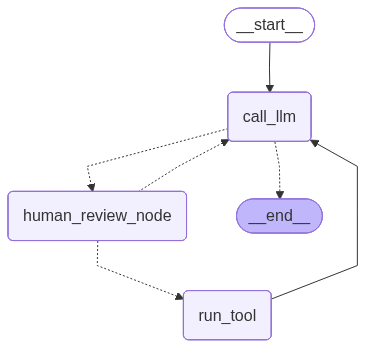

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
from langchain_core.messages import HumanMessage

initial_input = {"messages": [HumanMessage(content="Convert 100 usd to eur")]}
config = {"configurable": {"thread_id": "123"}}

graph.invoke(initial_input, config=config, stream_mode="updates")

[{'call_llm': {'messages': [AIMessage(content='I can help you convert 100 USD to EUR. Let me use the currency conversion tool for you.', additional_kwargs={'tool_calls': [{'id': 'call_00_gUaDmkKD7dajHFomHqydyIV1', 'function': {'arguments': '{"amount": 100, "from_currency": "USD", "to_currency": "EUR"}', 'name': 'convert_currency'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 187, 'total_tokens': 238, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 187}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache', 'id': 'aba93927-ba07-4481-86ea-44138bc5b91c', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--b3f522ee-7394-4ef3-bbcf-286d39872473-0', tool_calls=[{'name': 'convert_currency', 'args': {'amount': 100, 'from_currency':

In [11]:
graph.invoke(Command(resume={"action": "continue"}), config=config)

Converting 100.0 from USD to EUR


{'messages': [HumanMessage(content='Convert 100 usd to eur', additional_kwargs={}, response_metadata={}, id='58e8a378-9ee2-46be-8bff-1aa619e8efac'),
  AIMessage(content='I can help you convert 100 USD to EUR. Let me use the currency conversion tool for you.', additional_kwargs={'tool_calls': [{'id': 'call_00_gUaDmkKD7dajHFomHqydyIV1', 'function': {'arguments': '{"amount": 100, "from_currency": "USD", "to_currency": "EUR"}', 'name': 'convert_currency'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 187, 'total_tokens': 238, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 187}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache', 'id': 'aba93927-ba07-4481-86ea-44138bc5b91c', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run-

In [12]:
from langchain_core.messages import HumanMessage

initial_input = {"messages": [HumanMessage(content="Convert 100 usd to eur")]}
config = {"configurable": {"thread_id": "123"}}

graph.invoke(initial_input, config=config, stream_mode="updates")

[{'call_llm': {'messages': [AIMessage(content='I can help you convert 100 USD to EUR. Let me use the currency conversion tool for you.', additional_kwargs={'tool_calls': [{'id': 'call_00_IlmNOtrXrG72N0qOQDfXHhMm', 'function': {'arguments': '{"amount": 100, "from_currency": "USD", "to_currency": "EUR"}', 'name': 'convert_currency'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 268, 'total_tokens': 319, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 192}, 'prompt_cache_hit_tokens': 192, 'prompt_cache_miss_tokens': 76}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache', 'id': '1e2a7125-778f-4cf1-a377-7396d02d97e5', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--b9bcf0c7-ef63-4ed7-be02-66cecc4bda44-0', tool_calls=[{'name': 'convert_currency', 'args': {'amount': 100, 'from_currenc

In [13]:
graph.invoke(Command(resume={
    "action": "update",
    "data": {"amount": 100, "from_currency": "$", "to_currency": "EURO"}
}), config=config)

Converting 100.0 from $ to EURO


{'messages': [HumanMessage(content='Convert 100 usd to eur', additional_kwargs={}, response_metadata={}, id='58e8a378-9ee2-46be-8bff-1aa619e8efac'),
  AIMessage(content='I can help you convert 100 USD to EUR. Let me use the currency conversion tool for you.', additional_kwargs={'tool_calls': [{'id': 'call_00_gUaDmkKD7dajHFomHqydyIV1', 'function': {'arguments': '{"amount": 100, "from_currency": "USD", "to_currency": "EUR"}', 'name': 'convert_currency'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 187, 'total_tokens': 238, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 187}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache', 'id': 'aba93927-ba07-4481-86ea-44138bc5b91c', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run-

In [14]:
graph.invoke(Command(resume={
    "action": "update",
    "data": {"amount": 20, "from_currency": "USD", "to_currency": "EUR"}
}), config=config)

{'messages': [HumanMessage(content='Convert 100 usd to eur', additional_kwargs={}, response_metadata={}, id='58e8a378-9ee2-46be-8bff-1aa619e8efac'),
  AIMessage(content='I can help you convert 100 USD to EUR. Let me use the currency conversion tool for you.', additional_kwargs={'tool_calls': [{'id': 'call_00_gUaDmkKD7dajHFomHqydyIV1', 'function': {'arguments': '{"amount": 100, "from_currency": "USD", "to_currency": "EUR"}', 'name': 'convert_currency'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 187, 'total_tokens': 238, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 187}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281d48_prod0820_fp8_kvcache', 'id': 'aba93927-ba07-4481-86ea-44138bc5b91c', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run-